In [15]:
from datasets import load_dataset
import numpy as np 
import mahotas as mh 
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import glob
from PIL import Image

In [ ]:
# Fetching from an online hugging face dataset https://huggingface.co/datasets/hassanjbara/AI4MARS

print("Connecting to Hugging Face securely...")

ds = load_dataset(
    "hassanjbara/AI4MARS", 
    split="train", 
    streaming=True, 
)

features_list = []
labels_list = []

print("Extracting Haralick features from 5000 valid images...")

for example in ds:
    if example['label_mask'] is None:
        continue
        
    mask = np.array(example['label_mask'], dtype=np.int64).flatten()
    mask_filtered = mask[mask != 255] 
    
    if len(mask_filtered) == 0:
        continue
        
    dominant_class = np.argmax(np.bincount(mask_filtered))
    
    img = np.array(example['image'].convert('L'))
    h_features = mh.features.haralick(img).mean(axis=0)
    selected = h_features[[0, 1, 2, 8]]
    
    features_list.append(selected)
    labels_list.append(dominant_class)
    
    if len(features_list) % 250 == 0:
        print(f"Done: {len(features_list)}/5000")
        
    if len(features_list) == 5000:
        break

X = np.array(features_list)
y = np.array(labels_list)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nReady! Data shape: {X_scaled.shape}")

Connecting to Hugging Face securely...
Extracting Haralick features from 5000 valid images...
Done: 250/5000
Done: 500/5000
Done: 750/5000
Done: 1000/5000
Done: 1250/5000
Done: 1500/5000
Done: 1750/5000
Done: 2000/5000
Done: 2250/5000
Done: 2500/5000
Done: 2750/5000
Done: 3000/5000
Done: 3250/5000
Done: 3500/5000
Done: 3750/5000
Done: 4000/5000
Done: 4250/5000
Done: 4500/5000
Done: 4750/5000
Done: 5000/5000

Ready! Data shape: (5000, 4)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
print("Training Linear SVM model...")
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

# Run prediction on test set
y_pred = svm_model.predict(X_test)

# Results
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Training Linear SVM model...
Overall Accuracy: 65.30%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.51      0.59       348
           1       0.64      0.91      0.75       502
           2       0.68      0.15      0.25       137
           3       0.00      0.00      0.00        13

    accuracy                           0.65      1000
   macro avg       0.50      0.39      0.40      1000
weighted avg       0.65      0.65      0.61      1000



In [ ]:
class_names = {0: "Sand/Soil", 1: "Bedrock", 2: "Big Rock", 3: "Rover Tracks"}

def predict_custom_mars_data(image_paths, trained_model, fitted_scaler):
    valid_images = []
    features_list = []
    
    print(f"Processing {len(image_paths)} custom images...")
    
    for path in image_paths:
        try:
            img_pil = Image.open(path).convert('L')
            
            # Resize to reduce computational complexity 
            img_pil = img_pil.resize((512, 512)) 
            img_array = np.array(img_pil)
            
            # Extract Haralick Features
            h_features = mh.features.haralick(img_array).mean(axis=0)
            selected = h_features[[0, 1, 2, 8]] # Energy, Contrast, Correlation, Entropy
            
            features_list.append(selected)
            valid_images.append(img_pil)
            
        except Exception as e:
            print(f"Could not process {path}: {e}")
            
    if not features_list:
        print("No valid images processed.")
        return
        
    X_custom = np.array(features_list)
    X_custom_scaled = fitted_scaler.transform(X_custom)
    
    predictions = trained_model.predict(X_custom_scaled)
    
    num_images = len(valid_images)
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
    
    if num_images == 1:
        axes = [axes]
        
    for i, ax in enumerate(axes):
        ax.imshow(valid_images[i], cmap='gray')
        pred_label = class_names.get(predictions[i], f"Class {predictions[i]}")
        ax.set_title(f"SVM Thinks:\n{pred_label}", fontsize=14, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

Processing 3 custom images...


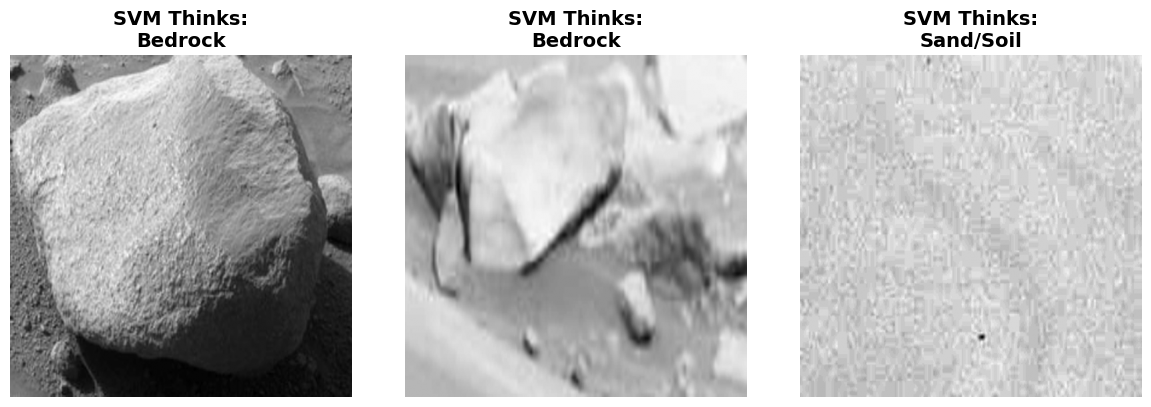

In [ ]:
custom_image_paths = glob.glob("my_mars_test/*.jpg")

predict_custom_mars_data(custom_image_paths[:4], svm_model, scaler)